![LeNet-5 Architecture](LeNet_fig.png)

Input → Conv1 → AvgPool → Conv2 → AvgPool → Conv3 → FC1 → FC2 → Output

---
### LeNet-5 Architecture

#### 1. Input Layer
- Size: 32 × 32 × 1
- MNIST images (28×28) are padded to 32×32.

#### 2. C1 — Convolution Layer
- Filters: 6
- Kernel (filter) size: 5×5
- Stride: 1
- Activation: Tanh

**Output size calculation:** $(n-f+1) = (32 - 5 + 1) = 28$

Output shape: $28 × 28 × 6$

#### 3. S2 — Subsampling (Average Pooling)
- Pool size: 2×2
- Stride: 2
- Type: Average Pooling
- Includes trainable scaling and bias

Output: $14 × 14 × 6$

#### 4. C3 — Convolution Layer
- Filters: 16
- Kernel size: 5×5
- Partial connectivity (not fully connected to all previous feature maps)

Output size: $(14 - 5 + 1) = 10$

Output shape: $10 × 10 × 16$

### 5. S4 — Subsampling
- 2×2 Average Pooling

Output: $5 × 5 × 16$

#### 6. C5 — Convolution Layer
- Filters: 120
- Kernel size: 5×5

Since input is 5×5, kernel covers entire feature map.

Output: $1 × 1 × 120$

### 7. F6 — Fully Connected Layer
- 84 neurons
- Activation: Tanh

### 8. Output Layer
- 10 neurons
- Originally used Gaussian RBF
- Modern implementations use Softmax




### Create the Model

In [102]:
import torch.nn as nn

class LeNet5(nn.Module):

    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()

        ## Convolutionnal Layer
        self.features = nn.Sequential(
            # C1
            nn.Conv2d(in_channels, 6, kernel_size=5),     # 32x32 → 28x28
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),        # 28x28 → 14x14
            # C3
            nn.Conv2d(6, 16, kernel_size=5),    # 14x14 → 10x10
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),        # 10x10 → 5x5
            # C5
            nn.Conv2d(16, 120, kernel_size=5),  # 5x5 → 1x1
            nn.Tanh()
        )

        ## Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Flatten(),          # 120 × 1 × 1 → 120
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [4]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms
import warnings
# warnings.filterwarnings("ignore", category=UserWarning)


# if torch.cuda.is_available():
#     device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
# else:
#     device = torch.device("cpu")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)


Using device: mps


### Download and transform the data

In [35]:
transform = transforms.Compose([
    transforms.ToTensor()
    ])

# Setup training data
train_dataset = datasets.CIFAR10(root='./data', # location to download data to
                               train=True,    # get training data
                               download=True, # download data if it doesn't exist on disk
                               transform=transform, # transformations on data
                            #    target_transform=None # you can transform labels as well
                            ) 
# Setup testing data
test_dataset  = datasets.CIFAR10(root='./data', 
                               train=False,   # get test data
                               download=True, 
                               transform=transform
                            )


Files already downloaded and verified
Files already downloaded and verified


In [18]:
# How many samples are there? 
len(train_dataset.data), len(train_dataset.targets), len(test_dataset.data), len(test_dataset.targets)

(50000, 50000, 10000, 10000)

In [19]:
train_dataset, len(train_dataset)

(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
            ),
 50000)

In [20]:
train_dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [9]:
train_dataset.data

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

In [21]:
train_dataset.data.shape

(50000, 32, 32, 3)

In [22]:
train_dataset.targets

[6,
 9,
 9,
 4,
 1,
 1,
 2,
 7,
 8,
 3,
 4,
 7,
 7,
 2,
 9,
 9,
 9,
 3,
 2,
 6,
 4,
 3,
 6,
 6,
 2,
 6,
 3,
 5,
 4,
 0,
 0,
 9,
 1,
 3,
 4,
 0,
 3,
 7,
 3,
 3,
 5,
 2,
 2,
 7,
 1,
 1,
 1,
 2,
 2,
 0,
 9,
 5,
 7,
 9,
 2,
 2,
 5,
 2,
 4,
 3,
 1,
 1,
 8,
 2,
 1,
 1,
 4,
 9,
 7,
 8,
 5,
 9,
 6,
 7,
 3,
 1,
 9,
 0,
 3,
 1,
 3,
 5,
 4,
 5,
 7,
 7,
 4,
 7,
 9,
 4,
 2,
 3,
 8,
 0,
 1,
 6,
 1,
 1,
 4,
 1,
 8,
 3,
 9,
 6,
 6,
 1,
 8,
 5,
 2,
 9,
 9,
 8,
 1,
 7,
 7,
 0,
 0,
 6,
 9,
 1,
 2,
 2,
 9,
 2,
 6,
 6,
 1,
 9,
 5,
 0,
 4,
 7,
 6,
 7,
 1,
 8,
 1,
 1,
 2,
 8,
 1,
 3,
 3,
 6,
 2,
 4,
 9,
 9,
 5,
 4,
 3,
 6,
 7,
 4,
 6,
 8,
 5,
 5,
 4,
 3,
 1,
 8,
 4,
 7,
 6,
 0,
 9,
 5,
 1,
 3,
 8,
 2,
 7,
 5,
 3,
 4,
 1,
 5,
 7,
 0,
 4,
 7,
 5,
 5,
 1,
 0,
 9,
 6,
 9,
 0,
 8,
 7,
 8,
 8,
 2,
 5,
 2,
 3,
 5,
 0,
 6,
 1,
 9,
 3,
 6,
 9,
 1,
 3,
 9,
 6,
 6,
 7,
 1,
 0,
 9,
 5,
 8,
 5,
 2,
 9,
 0,
 8,
 8,
 0,
 6,
 9,
 1,
 1,
 6,
 3,
 7,
 6,
 6,
 0,
 6,
 6,
 1,
 7,
 1,
 5,
 8,
 3,
 6,
 6,
 8,
 6,
 8,
 4,
 6,
 6,


In [24]:
train_dataset.transform

Compose(
    ToTensor()
)

In [ ]:
image, label = train_dataset[0]

print(type(image)) # Image → Tensor
print(image.shape) # Shape → [1, 32, 32]
print(label)       # Label → integer (0–9)
print(train_dataset.classes[label])     

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
6
frog


In [26]:
print(image.shape)
print(train_dataset.data[0].shape)

torch.Size([3, 32, 32])
(32, 32, 3)


In [ ]:
# PyTorch stores images as: [C, H, W] >> Color, Height, Width

# But Matplotlib expects: [H, W, C]

# print(image.shape) >> torch.Size([3, 32, 32])

# Channels = 3 (RGB)
# Height = 32
# Width = 32

# plt.imshow() expects: (32, 32, 3)

# image.permute(1,2,0) >> 
# Take dimension 1 → make it first
# Take dimension 2 → make it second
# Take dimension 0 → make it third


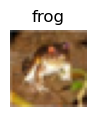

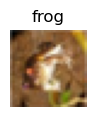

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2,1))
plt.imshow(image.permute(1,2,0))
# plt.title(f"Label: {label}")
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

plt.figure(figsize=(2,1))
plt.imshow(image.permute(2,1,0))
# plt.title(f"Label: {label}")
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

In [49]:
len(train_dataset.classes)

10

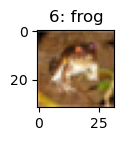

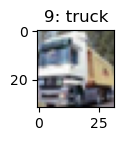

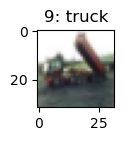

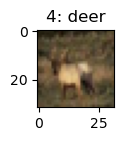

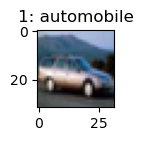

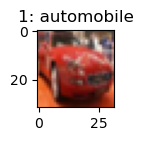

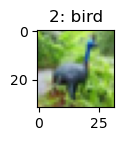

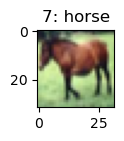

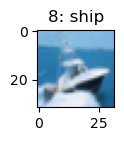

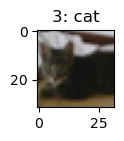

In [65]:

for idx in range(len(train_dataset.classes)):
    image, label = train_dataset[idx]
    # print(idx, label)
    plt.figure(figsize=(2,1))
    plt.imshow(image.permute(1,2,0))
    plt.title(f"{label}: {train_dataset.classes[label]}")
    plt.show()

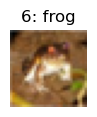

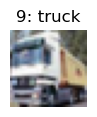

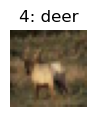

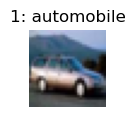

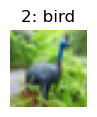

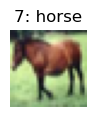

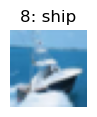

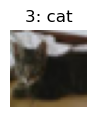

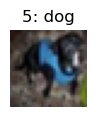

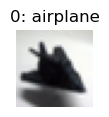

In [68]:
import matplotlib.pyplot as plt

shown_classes = []

for image, label in train_dataset:
    if label not in shown_classes:
        plt.figure(figsize=(2,1))
        plt.imshow(image.permute(1,2,0))
        plt.title(f"{label}: {train_dataset.classes[label]}")
        plt.axis("off")
        plt.show()
        
        shown_classes.append(label)

    if len(shown_classes) == 10:
        break


### Prepare The DataLoader

In [71]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32


train_loader = DataLoader(train_dataset,         # dataset to turn into iterable
                          batch_size=BATCH_SIZE, # number of datapoints or samples per batch 
                          shuffle=True           # shuffle data every epoch
                        )

test_loader  = DataLoader(test_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=False          # don't necessarily have to shuffle the testing data
                        )

print(f"Dataloaders: {train_loader, test_loader}") 
print(f"Length of train dataloader: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_loader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x33da04fa0>, <torch.utils.data.dataloader.DataLoader object at 0x33da06980>)
Length of train dataloader: 1563 batches of 32
Length of test dataloader: 313 batches of 32


In [19]:
# Total batches = 1875
# Each batch contains = 32 samples

In [72]:
len(train_loader), len(train_loader)*BATCH_SIZE

(1563, 50016)

In [76]:
last_batch = list(train_loader)[0]
print(last_batch[0].shape)

torch.Size([32, 3, 32, 32])


In [75]:
last_batch = list(train_loader)[-2]
print(last_batch[0].shape)

torch.Size([32, 3, 32, 32])


In [77]:
## Last Batch has less points as 50000/32 not exactly divisible

In [74]:
last_batch = list(train_loader)[-1]
print(last_batch[0].shape)

torch.Size([16, 3, 32, 32])


In [78]:
# Check out the training dataloader

images, labels = next(iter(train_loader)) 
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 32, 32])
torch.Size([32])


In [22]:
## iter(train_loader) >> This creates an iterator object.
## next(iterator) >> Gives the next batch.
## next(iter(train_loader)) >> Start iterating and give me the first batch.

# >> Output <<
# 32 images per batch
# 1 channel
# 32×32 pixels
# 32 labels

In [89]:
train_loader.dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

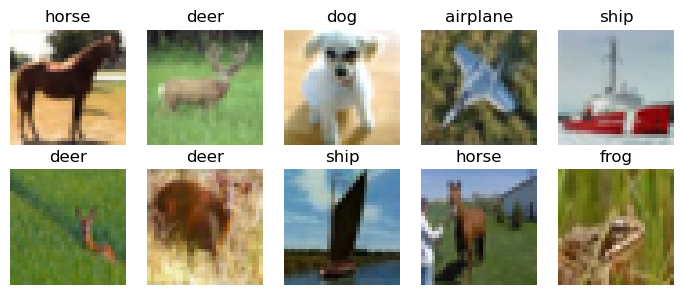

In [93]:
fig, axes = plt.subplots(2, 5, figsize=(7, 3))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i].permute(1,2,0))
    # ax.set_title(train_loader.categories.labels[i].item())
    ax.set_title(train_loader.dataset.classes[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [104]:
torch.manual_seed(123)

model = LeNet5(3, 10)
model.to(device)

# model = LeNet5().to(device)   # send the model to device
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(), lr=1e-3)

In [105]:
model.parameters()

<generator object Module.parameters at 0x33fb9d230>

In [106]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
LeNet5                                   --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       456
│    └─Tanh: 2-2                         --
│    └─AvgPool2d: 2-3                    --
│    └─Conv2d: 2-4                       2,416
│    └─Tanh: 2-5                         --
│    └─AvgPool2d: 2-6                    --
│    └─Conv2d: 2-7                       48,120
│    └─Tanh: 2-8                         --
├─Sequential: 1-2                        --
│    └─Flatten: 2-9                      --
│    └─Linear: 2-10                      10,164
│    └─Tanh: 2-11                        --
│    └─Linear: 2-12                      850
Total params: 62,006
Trainable params: 62,006
Non-trainable params: 0

In [107]:
model.eval()

LeNet5(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=84, bias=True)
    (2): Tanh()
    (3): Linear(in_features=84, out_features=10, bias=True)
  )
)

### Training and testing 

In [108]:
# Measure time
from timeit import default_timer as timer
from tqdm import tqdm

train_time_start = timer()

losses = [] 
epochs = 5

for epoch in tqdm(range(epochs)):

    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        # Send data to device
        images, labels = images.to(device), labels.to(device)
        # Optimizer zero grad
        optimizer.zero_grad()
        # Forward pass
        outputs = model(images)
        # Calculate loss
        loss = criterion(outputs, labels)
        # Loss backward
        loss.backward()
        # Optimizer step
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

    losses.append(running_loss/len(train_loader))

train_time_end = timer()

total_time = train_time_end - train_time_start
print(f"Train time on {device}: {total_time:.3f} seconds")

 20%|██        | 1/5 [00:12<00:49, 12.41s/it]

Epoch [1/5], Loss: 1.7843


 40%|████      | 2/5 [00:23<00:35, 11.81s/it]

Epoch [2/5], Loss: 1.5321


 60%|██████    | 3/5 [00:34<00:22, 11.37s/it]

Epoch [3/5], Loss: 1.4053


 80%|████████  | 4/5 [00:45<00:11, 11.27s/it]

Epoch [4/5], Loss: 1.3278


100%|██████████| 5/5 [00:56<00:00, 11.33s/it]

Epoch [5/5], Loss: 1.2723
Train time on mps: 56.637 seconds


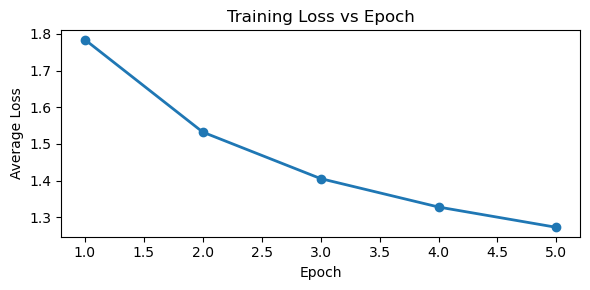

In [109]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, epochs+1), losses, 'o-', linewidth=2, markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss vs Epoch')
plt.tight_layout()
plt.show()

In [110]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 53.07%
